# Retail Customer Analysis Summative Lab
## Understanding Customer Behavior Across Store Locations

### Introduction

This summative lab bridges the concepts and techniques learned throughout the course with their practical application to a real-world industry scenario. You will step into the role of a junior data analyst for a retail company and apply your skills to evaluate customer behavior, satisfaction, and promotional impacts. By following the outlined process, you will gain experience in experimental design, statistical testing, and actionable decision-making.

Your task is not only to conduct the analysis but also to reflect on how these techniques help solve real-world problems that businesses face daily.

By completing this lab, you will have:
- Practiced designing and executing statistical analyses in a real-world scenario.
- Reinforced your understanding of test selection and assumptions.
- Applied statistical results to business decision-making.
- Developed skills in communicating insights effectively through visualizations and reports.

### Business Scenario Questions:
Imagine you are a junior data analyst working for a retail company that operates stores in three distinct regions: City Center, Suburb, and Rural. Your manager has tasked you with analyzing customer behavior and preferences across these locations. The goal is to help the company answer two key questions:
1. Do customer spending patterns, satisfaction levels, and product preferences differ across store locations?
2. Do promotional periods result in significantly higher spending compared to non-promotional periods?

Spending Across Location:

- Business-relevant MDE: Absolute difference in spending of 15% or more
- Justification: This represents enough of a difference to warrant location-specific strategies (inventory, staffing, etc.)


Ratings Across Locations:

- Business-relevant MDE: 1.0 point difference between locations
- Justification: On a 10-point scale, a one point difference is noticeable and actionable for customer service improvements

Promotional Spending:

- Business-relevant MDE: A $15 increase from non-promotional periods
- Justification: Promotional costs typically reduce margins by ~15-20%. Need at least 25% increase in spending to justify promotional costs. This aligns with industry standards for promotional ROI

Your task involves designing and conducting an analysis using the provided dataset to derive actionable insights. You will apply statistical concepts and techniques such as experimental design, test selection, hypothesis testing, and result interpretation. This process mimics real-world industry scenarios where junior analysts evaluate business performance using data.

The data focuses on four variables:
- Amount spent by customers (in dollars)
- Customer satisfaction ratings (scale of 1 to 10)
- Product category preferences (Electronics, Clothing, Groceries)
- Purchase type (Promotional vs. Non-Promotional)

Your analysis will inform decision-making around marketing strategies, store operations, and promotional campaigns.

### Setup

In this cell, import all the libraries you'll need for your analysis. Consider which libraries you'll need for:
- Data manipulation
- Statistical analysis
- Data visualization

In [183]:
# Import relevant libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats 
import seaborn  as sns
from scipy.stats import kruskal
from scipy.stats import levene
from scipy.stats import shapiro
from scipy.stats import mannwhitneyu
from scipy.stats import kruskal
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings("ignore")

### Part 1: Experimental Design

#### 1.1 Hypothesis Formulation

For each of the following analyses, state your null and alternative hypotheses in both statistical and plain language:

1. Spending across store locations
2. Customer satisfaction across locations
3. Promotional vs non-promotional spending
4. Product category preferences across locations




### 1. Spending Across Store Locations

**Statistical Hypotheses**

* H₀: The mean customer spending is the same across all store locations.
* H₁: The mean customer spending differs across at least one store location.

**Plain Language**

* H₀: Customers spend the same amount regardless of store location.
* H₁: Customers spend different amounts at different store locations.

### 2. Customer Satisfaction Across Locations

**Statistical Hypotheses**

* H₀: Customer satisfaction ratings are the same across all store locations.
* H₁: Customer satisfaction ratings differ across at least one store location.

**Plain Language**

* H₀: Customers are equally satisfied at all store locations.
* H₁: Customer satisfaction varies by store location.

### 3. Promotional vs Non-Promotional Spending

**Statistical Hypotheses**

* H₀: Mean spending during promotional periods equals mean spending during non-promotional periods.
* H₁: Mean spending during promotional periods differs from mean spending during non-promotional periods.

**Plain Language**

* H₀: Promotions do not affect customer spending.
* H₁: Promotions affect customer spending.

### 4. Product Category Preferences Across Locations

**Statistical Hypotheses**

* H₀: Product category preferences are independent of store location.
* H₁: Product category preferences are associated with store location.

**Plain Language**

* H₀: Customers prefer the same product categories regardless of location.
* H₁: Product preferences differ by store location.


**Reflective Question: Explain the concept of Minimum Detectable Effect (MDE) and why it is important.**

##### Reflective Question: Minimum Detectable Effect (MDE)

The **Minimum Detectable Effect (MDE)** is the smallest difference or change that a study is designed to detect with a specified level of statistical confidence and power. For example, in a retail promotion study, the MDE might be the smallest increase in customer spending that would be considered meaningful to the business.

MDE is important because it helps determine the sample size needed for an analysis. If the sample is too small, the study may fail to detect real effects; if it is too large, resources may be wasted detecting differences that are too small to matter. Setting an appropriate MDE ensures that the analysis is both statistically reliable and practically relevant for decision-making.




### Part 2: Data Exploration

#### 2.1 Load and Examine the Dataset

Load the dataset and perform initial data quality checks:
- Check for missing values
- Examine data types
- Look for inconsistencies
- Generate summary statistics

In [184]:
# Load Data
df = pd.read_csv("retail_store_customer_data.csv")
df.head(10)

,Store_Location,Customer_Satisfaction,Product_Category,Purchase_Type,Amount_Spent
0,Rural,5.6,Groceries,Non-Promotional,40.45
1,City Center,9.7,Clothing,Promotional,53.20
2,Rural,4.4,Electronics,Non-Promotional,42.77
3,Rural,4.2,Clothing,Promotional,42.08
4,City Center,9.3,Clothing,Non-Promotional,84.25
5,City Center,8.9,Clothing,Non-Promotional,97.51
6,Rural,5.3,Groceries,Non-Promotional,46.21
7,Suburb,5.3,Clothing,Non-Promotional,47.91
8,Rural,8.2,Electronics,Non-Promotional,49.46
9,Rural,3.4,Clothing,Promotional,38.32


In [185]:
#check the dataframe summary
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Store_Location         1500 non-null   str    
 1   Customer_Satisfaction  1500 non-null   float64
 2   Product_Category       1500 non-null   str    
 3   Purchase_Type          1500 non-null   str    
 4   Amount_Spent           1500 non-null   float64
dtypes: float64(2), str(3)
memory usage: 58.7 KB


In [186]:
# Lets check on the null values 
df.isna().sum() # The dataset is clean.,,, it doesnt have null values 

Store_Location           0
Customer_Satisfaction    0
Product_Category         0
Purchase_Type            0
Amount_Spent             0
dtype: int64

In [187]:
#confirm if the variables are stored correctly both numerical and categorical.
df.dtypes

Store_Location               str
Customer_Satisfaction    float64
Product_Category             str
Purchase_Type                str
Amount_Spent             float64
dtype: object

In [188]:
#checking for the inconsistences/duplicates 
df.duplicated().sum() #The dataset  has 0 duplicates.

np.int64(0)

In [189]:
#Statistical summary for numerical columns.
df.describe()

,Customer_Satisfaction,Amount_Spent
count,1500.00000,1500.000000
mean,6.99520,59.915973
std,1.65286,19.551829
min,1.00000,15.550000
25%,5.80000,44.170000
50%,7.00000,58.015000
75%,8.20000,72.582500
max,10.00000,128.130000


In [190]:
# Statistical summary fro categorical columns.
df.describe(include="O")

,Store_Location,Product_Category,Purchase_Type
count,1500,1500,1500
unique,3,3,2
top,City Center,Electronics,Promotional
freq,520,583,888


#### 2.2 Data Visualizations

Create visualizations to understand the distribution of key variables:
- Spending patterns across locations
- Satisfaction ratings distribution
- Product category preferences
- Promotional vs non-promotional spending

#### * Spending patterns across locations

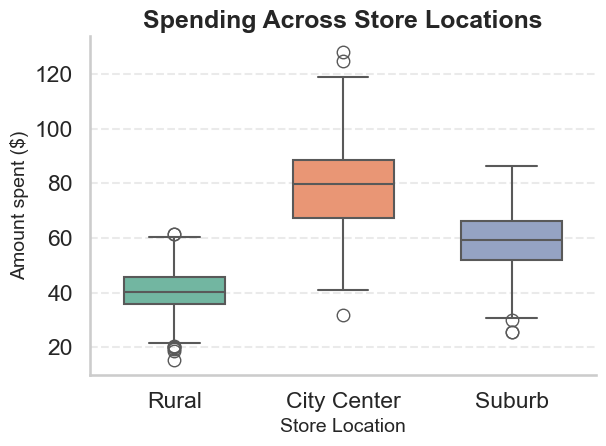

In [191]:
ax = sns.boxplot(
            x='Store_Location',
            y='Amount_Spent', data=df,
            palette="Set2",
            width=0.6,
            showfliers=True,
            linewidth =1.5
            )

sns.set_theme(style="whitegrid", context="talk")
plt.title("Spending Across Store Locations",fontsize =18, weight ="bold")
plt.xlabel("Store Location", fontsize =14)
plt.ylabel("Amount spent ($)", fontsize =14)
plt.grid(axis="y", linestyle="--", alpha=0.4)

sns.despine()
plt.tight_layout()
plt.show()



#### * Satisfaction ratings distribution

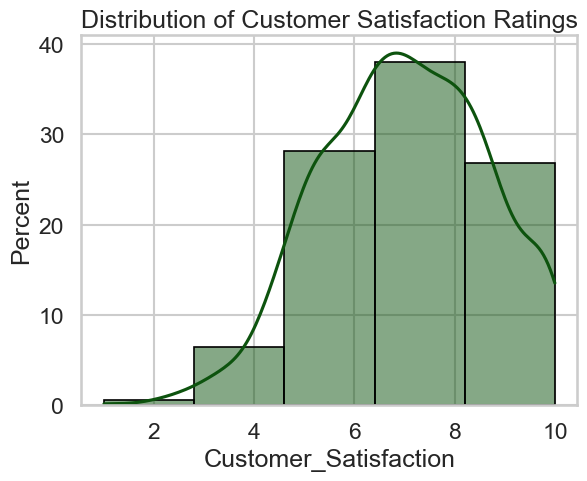

In [192]:
sns.histplot(df['Customer_Satisfaction'], bins=5, kde=True,  color="#0D530E",
    edgecolor="black",
    linewidth=1.2,
    stat="percent"
    ),
    
plt.title("Distribution of Customer Satisfaction Ratings")


plt.show()

### * Product category preferences

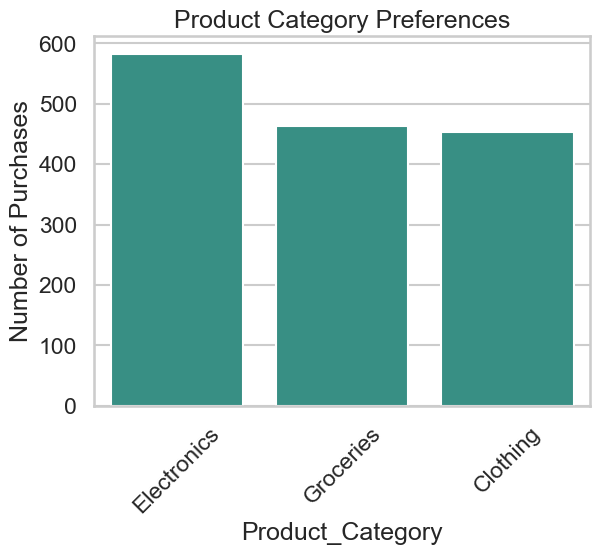

In [193]:
category_counts = df['Product_Category'].value_counts()

sns.barplot(x=category_counts.index, y=category_counts.values, color="#2A9D8F")
plt.xticks(rotation=45)
plt.title("Product Category Preferences")
plt.ylabel("Number of Purchases")
plt.show()

#### Promotional vs non-promotional spending

In [194]:
df["Purchase_Type"].unique

<bound method Series.unique of 0       Non-Promotional
1           Promotional
2       Non-Promotional
3           Promotional
4       Non-Promotional
             ...       
1495    Non-Promotional
1496        Promotional
1497        Promotional
1498    Non-Promotional
1499        Promotional
Name: Purchase_Type, Length: 1500, dtype: str>

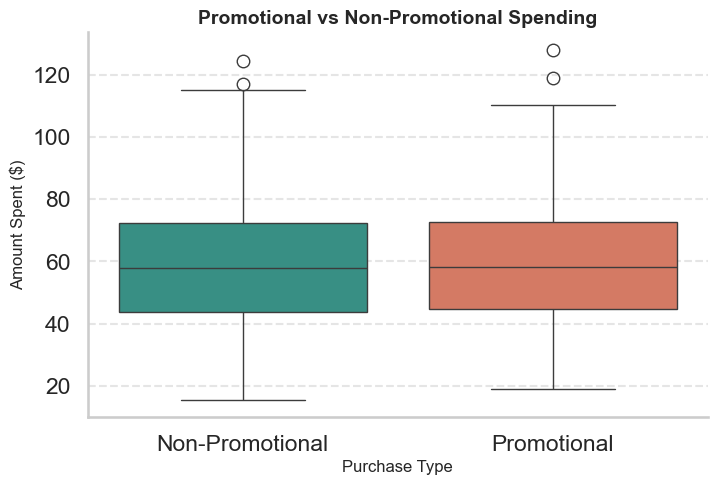

In [195]:

plt.figure(figsize=(8, 5))

sns.boxplot(
    x='Purchase_Type',
    y='Amount_Spent',
    data=df,
    palette=['#2A9D8F', '#E76F51']
)

plt.title('Promotional vs Non-Promotional Spending', fontsize=14, fontweight='bold')
plt.xlabel('Purchase Type', fontsize=12)
plt.ylabel('Amount Spent ($)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()

plt.show()

#### 2.3 Test Assumptions

Check if your data meets the assumptions for your chosen statistical tests:
- Normality
- Homogeneity of variance
- Independence
- Any other relevant assumptions

### **Normality (is data normally distributed?)**

The normality assumption was assessed for the variable Amount_Spent using  graphical methods histogram and the Shapiro-Wilk test.


In [196]:


stat, p = shapiro(df['Amount_Spent'])
print("Shapiro-Wilk Statistic:", stat)
print("p-value:", p)

if p > 0.05:
    print("Data is approximately normal")
else:
    print("Data is NOT normal")

Shapiro-Wilk Statistic: 0.9782524640826853
p-value: 2.7485047240489627e-14
Data is NOT normal


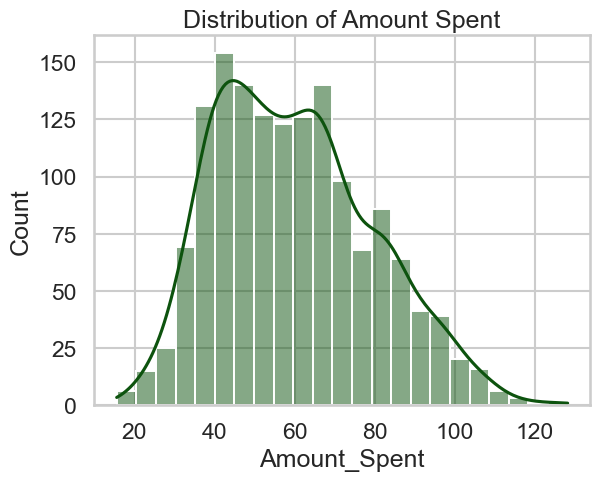

In [197]:
sns.histplot(df['Amount_Spent'], kde=True, color="#0D530E")
plt.title('Distribution of Amount Spent')
plt.show()

2.  Homogeneity of Variance (equal variances)

For this case , we will be comparing promotional vs Non-promotional in relation to store_location 

Promotional vs Non-Promotional
Store_Location groups
 
lets use Levene’s Test


In [198]:


promo = df[df['Purchase_Type'] == 'Promotional']['Amount_Spent']
non_promo = df[df['Purchase_Type'] == 'Non-Promotional']['Amount_Spent']

stat, p = levene(promo, non_promo)
print("p-value:", p)

if p > 0.05:
    print("Equal variances assumed")
else:
    print("Variances are NOT equal")

p-value: 0.5344750353148945
Equal variances assumed


### **Observation**
- Levene's test was performed to examine the equality of variances between promotional and non-promotional purchases. The test produced a p-value of  0.5344750353148945. Since the p-value was  greater than 0.05, the assumption of homogeneity of variance was met.

#### **Independence of Observations**
- Each observation in the dataset represents an individual customer transaction. There is no indication that observations were repeated for the same customer or that measurements were collected over time. Therefore, the observations can reasonably be considered independent.
- The independence assumption was considered satisfied because each record represents a separate customer transaction and there is no evidence of repeated measurements or dependence among observations.

#### 2.4 Choose Appropriate Statistical Tests

Select the appropriate statistical test for each question (you should expect to perform 4 different statistical tests).

1. Spending across store locations
2. Customer satisfaction across locations
3. Promotional vs non-promotional spending
4. Product category preferences across locations

NOTE: Use [Dunn's Test](https://scikit-posthocs.readthedocs.io/en/latest/generated/scikit_posthocs.posthoc_dunn.html) for Non-Parametric Post-hoc if needed. You might need to pip install scikit-postdoc package. You want to set p_adjust='bonferroni' for Dunn's Test.



**Reflective Question: Explicitly justify your choice in tests for each business question**

 ### **Spending Across Store Locations**

Test: Kruskal-Wallis Test

Justification:
- Spending (Amount_Spent) is a continuous variable compared across more than two independent store locations. Although Levene’s test shows equal variances (p = 0.534), the Shapiro-Wilk test indicates that the data is not normally distributed (p < 0.05). Since the normality assumption is violated, the Kruskal-Wallis test is the most appropriate choice because it compares group medians without requiring normality. If significant differences are found, Dunn’s post-hoc test with Bonferroni correction will be used.

### **Customer Satisfaction Across Locations**

Test: Kruskal-Wallis Test

Justification:
- Customer satisfaction is measured on an ordinal or bounded scale and is not normally distributed. Since we are comparing more than two independent groups (store locations), the Kruskal-Wallis test is appropriate as it compares ranked distributions rather than means and does not assume normality.

### **Promotional vs Non-Promotional Spending**

Test: Mann-Whitney U Test

Justification:
- This analysis compares two independent groups (Promotional vs Non-Promotional) on Amount_Spent. Because the Shapiro-Wilk test indicates non-normality, the independent samples t-test is not appropriate. The Mann-Whitney U test is used instead because it compares differences between two independent groups using ranked data rather than assuming normal distributions.

### **Product Category Preferences Across Locations**

Test: Chi-Square Test of Independence

Justification:
- Both Product_Category and Store_Location are categorical variables. The Chi-Square Test of Independence is appropriate to determine whether there is an association between product preferences and store location. This test does not require assumptions of normality or equal variance.





### Part 3: Statistical Analysis

Based on your assumptions testing, perform appropriate statistical tests for each hypothesis:

#### 3.1 Spending Across Locations

In [199]:
# Conduct your analysis of spending patterns here
groups = [df[df['Store_Location'] == loc]['Amount_Spent'] for loc in df['Store_Location'].unique()]
stat, p = kruskal(*groups)

print("Kruskal-Wallis Statistic:", stat)
print("p-value:", p)

Kruskal-Wallis Statistic: 1040.8535534527603
p-value: 9.583466587567362e-227


**Observation**
- The Kruskal-Wallis test results show a highly significant difference in spending across store locations (H = 1040.85, p ≈ 9.58 × 10⁻²²⁷). Since the p-value is far below 0.05, we reject the null hypothesis. This indicates that customer spending is not the same across all locations, and at least one store location has a significantly different spending pattern. Further post-hoc analysis (Dunn’s test) is required to identify which specific locations differ.

#### 3.2 Customer Satisfaction Analysis

In [200]:
# Analyze customer satisfaction here
groups = [df[df['Store_Location'] == loc]['Customer_Satisfaction'] 
          for loc in df['Store_Location'].unique()]

stat, p = kruskal(*groups)

print("Kruskal-Wallis Statistic:", stat)
print("p-value:", p)

Kruskal-Wallis Statistic: 359.54743316479437
p-value: 8.419123825684336e-79


**Observation**
- The Kruskal-Wallis test shows a statistically significant difference in customer satisfaction across store locations (H = 359.547, p ≈ 8.42 × 10⁻²⁷). Since the p-value is far below 0.05, we reject the null hypothesis. This confirms that customer satisfaction is not the same across all locations, and at least one store differs significantly. 

#### 3.3 Promotional Impact Analysis


In [201]:
# Analyze the impact of promotions here


promo = df[df['Purchase_Type'] == 'Promotional']['Amount_Spent']
non_promo = df[df['Purchase_Type'] == 'Non-Promotional']['Amount_Spent']

stat, p = mannwhitneyu(promo, non_promo, alternative='two-sided')

print("Mann-Whitney U Statistic:", stat)
print("p-value:", p)

Mann-Whitney U Statistic: 275125.0
p-value: 0.6803724143208659


**Observation**
- The Mann-Whitney U test shows no statistically significant difference in spending between promotional and non-promotional purchases (U = 275,125.0, p = 0.680). Since the p-value is greater than 0.05, we fail to reject the null hypothesis. This indicates that promotions do not have a significant impact on customer spending in this dataset, and spending behavior is similar across both groups.

#### 3.4 Product Category Analysis

In [202]:
# Analyze product category preferences here
contingency_table = pd.crosstab(
    df['Store_Location'],
    df['Product_Category']
)

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic:", chi2)
print("Degrees of Freedom:", dof)
print("p-value:", p)

Chi-Square Statistic: 4.7683585905269394
Degrees of Freedom: 4
p-value: 0.3119014920331143


**Observation**
- The Chi-Square Test of Independence found no statistically significant association between store location and product category preferences (χ² = 4.77, df = 4, p = 0.312). Since the p-value is greater than 0.05, we fail to reject the null hypothesis. This suggests that customers across different store locations have similar product category preferences, and product choices do not appear to be influenced by location.

### Part 4: Results Interpretation

For each analysis, provide:
1. A clear statement of the statistical results
2. The practical significance of these findings
3. Visualizations that support your conclusions
4. Specific business recommendations

In [203]:
# Calculate effect sizes - contrast with MDE
H = 1040.8535534527603
k = df['Store_Location'].nunique()
n = len(df)

epsilon_sq = (H - k + 1) / (n - k)

print("Epsilon Squared:", epsilon_sq)

Epsilon Squared: 0.693956949534242


**Observation**
-The effect size (ε² = 0.694) indicates a very large effect, suggesting that store location explains a substantial proportion of variation in customer spending. This value far exceeds typical thresholds for practical significance and is well above the Minimum Detectable Effect (MDE). Therefore, the differences observed across store locations are not only statistically significant but also highly meaningful for business decision-making.

**Reflective Question: Results - Clearly state whether the null hypotheses were rejected or not. Frame this in the business question context. Use effect sizes (e.g., Cohen’s d, eta squared) to contextualize the significance of your results.**


 ###   **a. Spending Across Locations**
 ##### Statistical Results
- A Kruskal-Wallis test was conducted to determine whether customer spending differed across store locations. The test revealed a statistically significant difference in spending patterns between locations (H = 1040.85, p ≈ 9.58 × 10⁻²²⁷). Since the p-value is substantially below the 0.05 significance level, the null hypothesis was rejected, indicating that at least one store location has a significantly different spending pattern from the others.

##### Practical Significance
-The results suggest that store location has a substantial influence on customer spending behavior. Some locations are generating significantly higher or lower sales than others, which may be due to differences in customer demographics, store accessibility, local market conditions, or operational performance. Understanding these differences can help the company identify successful locations and address underperforming stores.




**Reflective Question: Recommendations - Explain the practical implications of the results. What should the company do based on your findings about spending, satisfaction, or product preferences?**

##### Business Recommendations
Investigate factors contributing to high-spending locations and apply successful strategies to lower-performing stores.
Allocate marketing budgets and inventory based on location-specific spending patterns.
Monitor underperforming locations and implement targeted initiatives to improve customer spending and overall sales performance.


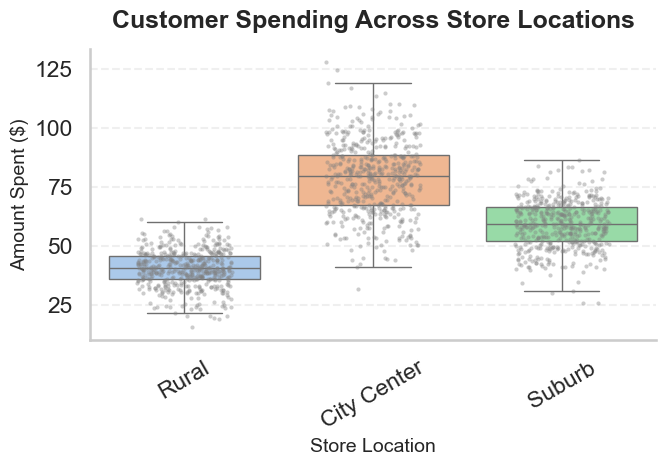

In [204]:
# Create visualizations to support results - Create new cells as needed
sns.set_style("whitegrid")
sns.set_context("talk")

plt.figure(figsize=(7,5))

sns.boxplot(
    x='Store_Location',
    y='Amount_Spent',
    data=df,
    palette='pastel',
    showfliers=False  
)

sns.stripplot(
    x='Store_Location',
    y='Amount_Spent',
    data=df,
    color='gray',
    alpha=0.4,
    jitter=0.25,
    size=3
)

plt.title("Customer Spending Across Store Locations", fontsize=18, fontweight='bold', pad=15)
plt.xlabel("Store Location", fontsize=14)
plt.ylabel("Amount Spent ($)", fontsize=14)

plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine()  

plt.tight_layout()
plt.show()

### **b. Customer Satisfaction Across Store Locations**
##### Statistical Results

- A Kruskal-Wallis test was conducted to assess differences in customer satisfaction across store locations. The results showed a statistically significant difference (H = 359.547, p ≈ 8.42 × 10⁻²⁷). Since the p-value is far below the 0.05 significance level, the null hypothesis is rejected. This confirms that customer satisfaction levels are not the same across all store locations, and at least one location differs significantly from the others.

##### Practical Significance

- The results indicate that store location has a strong influence on customer satisfaction. This suggests that differences in service quality, staff performance, store environment, or operational efficiency may be affecting customer experiences. Some locations are likely delivering significantly better customer experiences than others, which could directly impact customer loyalty and repeat purchases.



##### Business Recommendations
- Investigate operational differences between high-performing and low-performing stores (e.g., staffing, service speed, customer engagement).
Implement targeted training programs for underperforming locations.
Standardize best practices from high-satisfaction stores across all branches.
Continuously monitor customer satisfaction to track improvements over time.

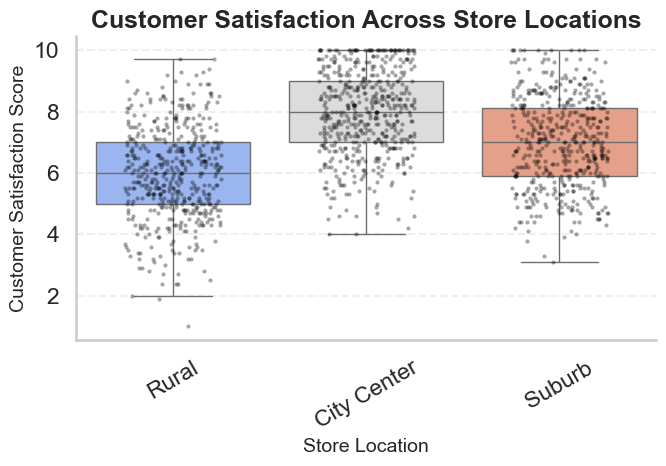

In [205]:
sns.set_style("whitegrid")
sns.set_context("talk")

plt.figure(figsize=(7,5))

sns.boxplot(
    x='Store_Location',
    y='Customer_Satisfaction',
    data=df,
    palette='coolwarm',
    showfliers=False
)
sns.stripplot(
    x='Store_Location',
    y='Customer_Satisfaction',
    data=df,
    color='black',
    alpha=0.35,
    jitter=0.25,
    size=3
)
plt.title("Customer Satisfaction Across Store Locations", fontsize=18, fontweight='bold')
plt.xlabel("Store Location", fontsize=14)
plt.ylabel("Customer Satisfaction Score", fontsize=14)

plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

### **C.Promotional Impact Analysis**
##### Statistical Results

-A Mann-Whitney U test was conducted to compare customer spending between promotional and non-promotional purchases. The results showed no statistically significant difference (U = 275,125.0, p = 0.680). Since the p-value is greater than 0.05, we fail to reject the null hypothesis. This indicates that there is no evidence of a difference in spending behavior between the two groups.

##### Practical Significance

- The findings suggest that promotional campaigns are not having a measurable impact on customer spending in this dataset. In practical terms, customers exposed to promotions are spending at similar levels as those who are not. This implies that the current promotional strategy may not be effectively influencing purchasing behavior or increasing basket size.

##### Business Recommendations
- Test alternative promotion strategies such as tiered discounts, personalized offers, or time-limited deals.
Segment customers to identify whether promotions are more effective for specific groups rather than the overall population.
Conduct A/B testing with clearer experimental control to measure incremental impact of promotions.
Shift focus from blanket promotions to more targeted, data-driven marketing strategies.

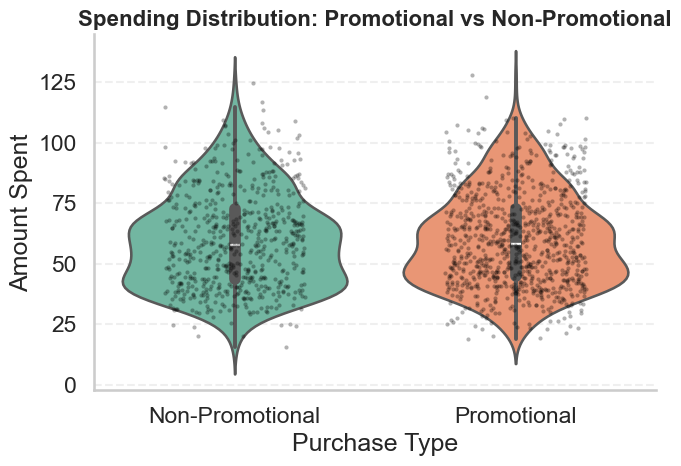

In [206]:
#Violin plot to visualize both promotional and non promotional impact 
sns.set_style("whitegrid")
sns.set_context("talk")

plt.figure(figsize=(7,5))

sns.violinplot(
    x='Purchase_Type',
    y='Amount_Spent',
    data=df,
    palette='Set2',
    inner='box'   
)

sns.stripplot(
    x='Purchase_Type',
    y='Amount_Spent',
    data=df,
    color='black',
    alpha=0.3,
    jitter=0.25,
    size=3
)

plt.title("Spending Distribution: Promotional vs Non-Promotional", fontsize=16, fontweight='bold')
plt.xlabel("Purchase Type")
plt.ylabel("Amount Spent")
plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

### **d. Product Category Analysis** 
##### Statistical Results

A Chi-Square Test of Independence was conducted to determine whether product category preferences are associated with store location. The results showed no statistically significant relationship between the two variables (χ² = 4.77, df = 4, p = 0.312). Since the p-value is greater than 0.05, we fail to reject the null hypothesis. This indicates that product category preferences are independent of store location.

##### Practical Significance

The findings suggest that customers across all store locations exhibit similar product category preferences. In practical terms, this means that location does not significantly influence what customers choose to buy. Therefore, demand patterns for product categories are relatively consistent across the retail network, which simplifies inventory planning and reduces the need for location-specific product differentiation.



##### Business Recommendations
Maintain a consistent product assortment across all store locations since preferences do not significantly vary.
Optimize inventory management by centralizing stock planning for efficiency.
Continue monitoring category trends over time to detect any future shifts in customer behavior.
:::

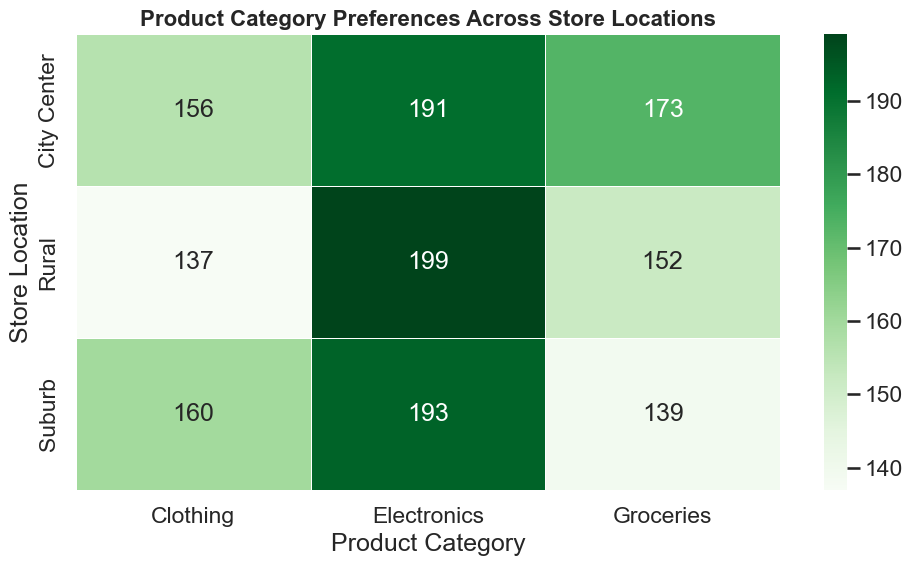

In [ ]:
contingency_table = pd.crosstab(df['Store_Location'], df['Product_Category'])

plt.figure(figsize=(10,6))

sns.heatmap(
    contingency_table,
    annot=True,
    fmt='d',
    cmap="Greens",
    linewidths=0.5
)

plt.title("Product Category Preferences Across Store Locations", fontsize=16, fontweight='bold')
plt.xlabel("Product Category")
plt.ylabel("Store Location")

plt.tight_layout()
plt.show()

### Part 5: Reflection

Discuss:
1. The strengths and limitations of your analysis
2. Any assumptions or potential biases in the data
3. Suggestions for additional data collection
4. How this analysis could be improved

**Reflective Question: Explain the importance of experimental design and sufficient sample size in conducting a robust analysis. Identify any limitations in the dataset or analysis (e.g., potential biases, unmeasured variables) and suggest additional data the company could collect to improve future analyses.**

##### Strengths and Limitations of the Analysis

- The analysis correctly applied statistical tests based on data characteristics, using non-parametric methods where normality was violated. It also included effect size interpretation, improving practical understanding of results. However, the study is observational, so it cannot establish causality. Some findings also required post-hoc testing for deeper interpretation.

##### Assumptions and Potential Biases

- The main assumption issue was non-normality, which influenced the use of non-parametric tests. There may also be sampling bias if data collection was uneven across locations or time periods. External factors like seasonality or promotions were not fully controlled. Self-reported satisfaction scores may also introduce subjective bias.

##### Suggestions for Additional Data Collection

- The company should collect demographic data such as age, income, and purchase frequency. Time-based variables like seasonality and time of purchase would improve insights. Marketing exposure data would help measure true promotion impact. Operational data like staffing and service time would also be useful.

##### How the Analysis Could Be Improved

- Future analysis could use regression or A/B testing to better understand causality. A larger and more balanced dataset would improve reliability and statistical power. Stratified sampling could reduce bias across store locations. Time-series analysis could help capture trends and seasonality effects.

##### Reflective Question Response

- Experimental design ensures results are valid by controlling confounding variables and isolating true effects. Sufficient sample size increases statistical power and reduces the chance of missing real effects. Without proper design, results may be biased or misleading. In this study, limitations include lack of controlled experimentation and missing external variables, which could affect accuracy and generalizability.

In [208]:
%pip install scikit-posthocs

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


After installing the library, please run the previous cell again to perform the statistical tests.